# CIFAR - Autoencoder

- Import images as in project 1
- Create CNN autoencoder
- Follow architecture from video (https://www.udemy.com/course/deeplearning_x/learn/lecture/27854970#overview minute:second = 1:10)
- Plot train/test loss over epochs

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader,TensorDataset,Subset

# for getting summary info on models
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
transform = transforms.Compose([ transforms.ToTensor(),
                                 transforms.Normalize([.5,.5,.5],[.5,.5,.5]),
                              ])

# Import CIFA10 dataset
root_dir = '../sample_data/cifar10'
cifar10_train = datasets.CIFAR10(root=root_dir, train=True,  download=True, transform=transform)
cifar10_test  = datasets.CIFAR10(root=root_dir, train=False, download=True, transform=transform)

# split the devtest into two separate sets
print('cifar10_train.data.shape =', cifar10_train.data.shape)
print('cifar10_test.data.shape =', cifar10_test.data.shape)
print('cifar10_train.targets.shape =', len(cifar10_train.targets))
print('cifar10_test.targets.shape =', len(cifar10_test.targets))

# Create labels to names mapping:
labels2names = dict(zip(sorted(set(cifar10_train.targets)), cifar10_train.classes))
print('labels2names: ', labels2names)

cifar10_train.data.shape = (50000, 32, 32, 3)
cifar10_test.data.shape = (10000, 32, 32, 3)
cifar10_train.targets.shape = 50000
cifar10_test.targets.shape = 10000
labels2names:  {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


# Split into train/test/dev sets

In [4]:
randidx = np.random.permutation(len(cifar10_test))   # a random permutation of indices
devset  = Subset(cifar10_test,randidx[:6000]) # Subset for devset
testset = Subset(cifar10_test,randidx[6000:]) # Subset for test

# transform to dataloaders
batchsize    = 1000
train_loader = DataLoader(cifar10_train,batch_size=batchsize,shuffle=True,drop_last=True)
dev_loader   = DataLoader(devset,  batch_size=len(devset)) # note: devtest in batches!
test_loader  = DataLoader(testset, batch_size=len(testset))

In [5]:
# check size (should be images X channels X width X height
print( train_loader.dataset.data.shape )
print( len(train_loader.dataset.targets) )

print( test_loader.dataset.dataset.data.shape )
print( len(test_loader.dataset.dataset.targets) )

print( dev_loader.dataset.dataset.data.shape )
print( len(dev_loader.dataset.dataset.targets) )

print('\nData value range:')
print('train_loader: ', train_loader.dataset.data.min(), train_loader.dataset.data.max() )
print('test_loader: ', test_loader.dataset.dataset.data.min(), test_loader.dataset.dataset.data.max() )
print('test_loader: ', test_loader.dataset.dataset.data.min(), test_loader.dataset.dataset.data.max() )
print('dev_loader: ', dev_loader.dataset.dataset.data.min(), dev_loader.dataset.dataset.data.max() )

(50000, 32, 32, 3)
50000
(10000, 32, 32, 3)
10000
(10000, 32, 32, 3)
10000

Data value range:
train_loader:  0 255
test_loader:  0 255
test_loader:  0 255
dev_loader:  0 255


# Show some data

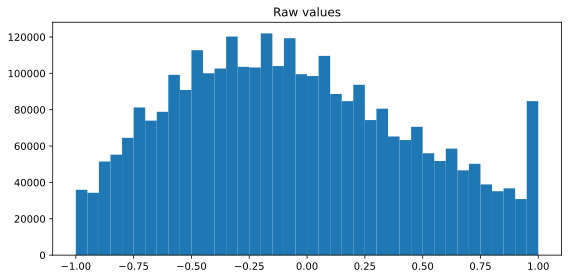

In [6]:
# Show histogram of normalized data for each plane/channel
fig, axs = plt.subplots(1,1, figsize=(8,4))
X,_ = next(iter(train_loader))
axs.hist(X.data.flatten(), 40)
axs.set_title('Raw values')

fig.tight_layout()
plt.show()

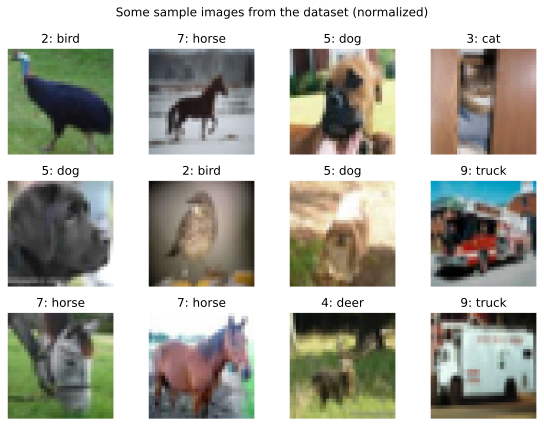

In [7]:
# Show some sample images
fig = plt.figure(figsize=(8,6))
for i, (X,y) in enumerate(train_loader):
    if i > 11: break
    ax = fig.add_subplot(3,4,i+1)
    img = X[0].permute(1, 2, 0).numpy().astype(np.float32)
    img = (img * 0.5) + 0.5  # unnormalize
    ax.imshow(img)  # transpose to HWC for display
    ax.set_title(f'{y[0].item()}: {labels2names[y[0].item()]}')
    ax.axis('off')
fig.suptitle('Some sample images from the dataset (normalized)')
fig.tight_layout()
plt.show()

# Create AE Model

In [8]:
from numpy import indices


def makeTheAE(lr:float=.001, printtoggle=False):
    class cifar10ae(nn.Module):
        def __init__(self,printtoggle):
            super().__init__()
            
            # torch.manual_seed(1)
            self.print = printtoggle

            # encoding layer
            self.enc = nn.Sequential(
                nn.Conv2d(3,16,4,padding=1,stride=2), # output size: (32+2*1-4)/2 + 1 = 16
                nn.ReLU(),
                nn.BatchNorm2d(16),
                nn.Conv2d(16,32,4,padding=1,stride=2), # output size: (16+2*1-4)/2 + 1 = 8
                nn.ReLU(),
                nn.BatchNorm2d(32),
                nn.Conv2d(32,64,4,padding=1,stride=2), # output size: (8+2*1-4)/2 + 1 = 4
                nn.ReLU(),
                nn.BatchNorm2d(64),
            )

            # decoding layer
            self.dec = nn.Sequential(
                nn.ConvTranspose2d(64,32,4,padding=1,stride=2), # output size: (4-1)*2 - 2*1 + 1*(4 - 1) + 0 + 1 = 8
                nn.ReLU(),
                nn.BatchNorm2d(32),
                nn.ConvTranspose2d(32,16,4,padding=1,stride=2), # output size: (8-1)*2 - 2*1 + 1*(4 - 1) + 0 + 1 = 16
                nn.ReLU(),
                nn.BatchNorm2d(16),
                nn.ConvTranspose2d(16,3,4,padding=1,stride=2), # output size: (16-1)*2 - 2*1 + 1*(4 - 1) + 0 + 1 = 32
                nn.BatchNorm2d(3),
                nn.Sigmoid(),
            )

        def forward(self,x):
            x = self.enc(x)
            if self.print: print(f'enc.shape: {x.shape}')

            x = self.dec(x)
            if self.print: print(f'dec.shape: {x.shape}')
            return x
        
    net = cifar10ae(printtoggle=printtoggle)
    lossfun = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(),lr=lr,weight_decay=1e-5)

    return net,lossfun,optimizer

# test the model with one batch
net,lossfun,optimizer = makeTheAE(printtoggle=True)
X,_ = next(iter(train_loader))
X = X[:7,:,:,:]
print(f'X.shape: {X.shape}')
yHat = net(X)
print(f'yHat.shape: {yHat.shape}')

# now let's compute the loss and accuracy
loss = lossfun(yHat, X)
print(f'Loss: {loss}')

net_summary,_,_ = makeTheAE() 
summary(net_summary,(3,32,32), device='cpu')

X.shape: torch.Size([7, 3, 32, 32])
enc.shape: torch.Size([7, 64, 4, 4])
dec.shape: torch.Size([7, 3, 32, 32])
yHat.shape: torch.Size([7, 3, 32, 32])
Loss: 0.506058394908905
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 16, 16]             784
              ReLU-2           [-1, 16, 16, 16]               0
       BatchNorm2d-3           [-1, 16, 16, 16]              32
            Conv2d-4             [-1, 32, 8, 8]           8,224
              ReLU-5             [-1, 32, 8, 8]               0
       BatchNorm2d-6             [-1, 32, 8, 8]              64
            Conv2d-7             [-1, 64, 4, 4]          32,832
              ReLU-8             [-1, 64, 4, 4]               0
       BatchNorm2d-9             [-1, 64, 4, 4]             128
  ConvTranspose2d-10             [-1, 32, 8, 8]          32,800
             ReLU-11             [-1, 32, 8, 8]          

In [9]:
# a function that trains the model
def trainTheAE(train_set_loader, dev_set_loader, device, lr, numepochs:int=3):
  # create a new model
  net,lossfun,optimizer = makeTheAE(lr=lr)
  net.to(device)

  # initialize losses
  train_loss = torch.zeros(numepochs)
  dev_loss = torch.zeros(numepochs)
  
  # loop over epochs
  for epochi in range(numepochs):
    net.train()
    
    batchLoss = []
    for X,_ in train_set_loader:
      X = X.to(device)

      # forward pass and loss
      yHat = net(X)
      X = .5 * X + .5  # unnormalize
      loss = lossfun(yHat, X)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      
      batchLoss.append(loss.item())
    # end batches
    train_loss[epochi] = np.mean(batchLoss)
    
    # Evaluate on dev data
    net.eval()
    X_dev,_ = next(iter(dev_set_loader))
    X_dev = X_dev.to(device)
    with torch.no_grad():
      yHat = net(X_dev)
      X_dev = .5 * X_dev + .5  # unnormalize
      dev_loss[epochi] = lossfun(yHat, X_dev).cpu().item()
      
    print(f'epoch {epochi+1}/{numepochs}: '
          f'train loss: {train_loss[epochi]:.4f} '
          f'dev loss: {dev_loss[epochi]:.4f} ',end='\r' )
  # end epochs

  # function output
  return train_loss, dev_loss, net

In [10]:
train_loss, dev_loss, net = trainTheAE(train_loader, dev_loader, device, lr=.001, numepochs=40)

In [11]:
# Run on test_set
X_test,_ = next(iter(test_loader))
X_test = X_test.to(device)

with torch.no_grad():
    yHat_test = net(X_test).cpu().detach()
    X_test = .5 * X_test + .5 # unnormalize
X_test = X_test.cpu().detach().to(torch.float32)

test_loss = lossfun(yHat_test,X_test).item()
print('testLoss:', test_loss)

testLoss: 0.000749739701859653


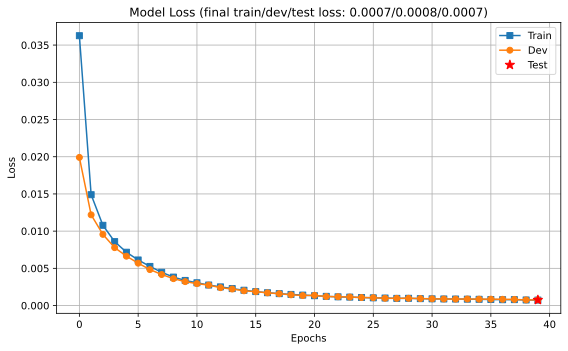

In [12]:
# Plot losses
fig,axs = plt.subplots(1,1,figsize=(8,5))

axs.plot(train_loss,'s-',label='Train')
axs.plot(dev_loss,'o-',label='Dev')
axs.plot(len(train_loss)-1, test_loss,'r*',markersize=10, label='Test')
axs.set_ylabel('Loss')
axs.set_title('Model Loss (final train/dev/test loss: '
              f'{train_loss[-1]:.4f}/{dev_loss[-1]:.4f}/{test_loss:.4f})')

axs.grid(True)
axs.legend()
axs.set_xlabel('Epochs')

fig.tight_layout()
plt.show()

(2, 8)


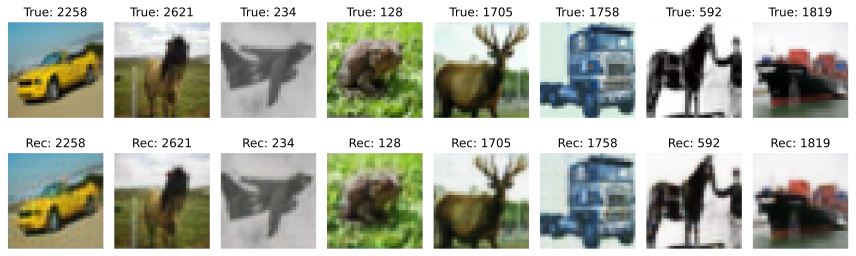

In [13]:
# Randomly show real and reconstructed images from test set
numimages = 8
idxs = np.random.choice(X_test.shape[0], numimages, replace=False)

fig,axs = plt.subplots(2,len(idxs),figsize=(12,4))
print(axs.shape)
for i, idx in enumerate(idxs):
    img_orig = X_test[idx].permute(1, 2, 0).numpy().astype(np.float32)
    # img_orig = (img_orig * 0.5) + 0.5  # unnormalize
    
    img_recon = yHat_test[idx].permute(1, 2, 0).numpy().astype(np.float32)
    # img_recon = (img_recon * 0.5) + 0.5  # unnormalize
    
    axs[0,i].imshow(img_orig)
    axs[0,i].set_title(f'True: {idx}')
    
    axs[1,i].imshow(img_recon)
    axs[1,i].set_title(f'Rec: {idx}')
    
    
for a in axs.flatten():
    a.axis('off')

fig.tight_layout()
plt.show()

new_img.shape:  (534, 1080, 3)
new_img.min:  0  new_img.max:  255


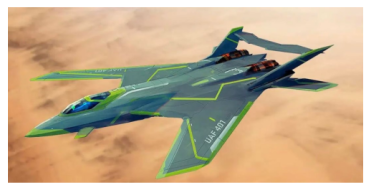

In [121]:
from PIL import Image
import requests
from io import BytesIO

# URL of the image
url = "https://preview.redd.it/pvcn46xd2md51.jpg?width=1080&crop=smart&auto=webp&s=da81e05968473df10c5e357172c6d0d4433a5497"

# Fetch the image
response = requests.get(url)
if response.status_code == 200:
    new_img = Image.open(BytesIO(response.content))
    new_img = np.array(new_img,dtype=np.uint8)
    print('new_img.shape: ', new_img.shape)
    print('new_img.min: ', np.min(new_img), ' new_img.max: ', np.max(new_img))
    fig = plt.figure()
    plt.imshow(new_img)
    plt.axis('off')
    plt.show()
else:
    print(f"Failed to fetch the image. Status code: {response.status_code}")

new_img.shape:  (534, 1080, 3)
scaled_new_img.shape:  torch.Size([3, 32, 32])
scaled_new_img.min:  tensor(-0.8902)  scaled_new_img.max:  tensor(0.9529)


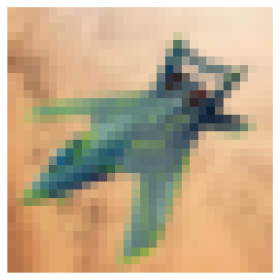

In [122]:
# Normalize the tensor
new_img_transform = transforms.Compose([
    transforms.ToPILImage(),      # NumPy -> PIL Image
    transforms.Resize((32,32)), # Resize to 32x32
    transforms.ToTensor(),
    transforms.Normalize([.5,.5,.5],[.5,.5,.5]),
])

print('new_img.shape: ', new_img.shape)

scaled_new_img = new_img_transform(new_img)
print('scaled_new_img.shape: ', scaled_new_img.shape)  # Should print torch.Size([3, 32, 32])
print('scaled_new_img.min: ', scaled_new_img.min(), ' scaled_new_img.max: ', scaled_new_img.max())

fig = plt.figure()
scaled_new_img_plt = .5 * scaled_new_img + .5  # unnormalize for display
plt.imshow(scaled_new_img_plt.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [123]:
# Run on absolutely new image
scaled_new_img_test = scaled_new_img.to(device).reshape(
    1, scaled_new_img.shape[0], scaled_new_img.shape[1], scaled_new_img.shape[2])
print('scaled_new_img_test.shape', scaled_new_img_test.shape)
print('scaled_new_img_test.min: ', scaled_new_img_test.min(), ' scaled_new_img_test.max: ', scaled_new_img_test.max())

with torch.no_grad():
    yHat_new_img_test = net(scaled_new_img_test).detach()
    new_img_test_loss = lossfun(yHat_new_img_test, scaled_new_img_test).item()
yHat_new_img_test = yHat_new_img_test.cpu().detach()
print('new_img_test_loss:', new_img_test_loss)

scaled_new_img_test.shape torch.Size([1, 3, 32, 32])
scaled_new_img_test.min:  tensor(-0.8902, device='cuda:0')  scaled_new_img_test.max:  tensor(0.9529, device='cuda:0')
new_img_test_loss: 0.1866610050201416


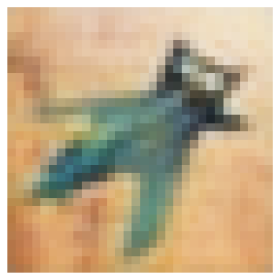

In [124]:
# Display reconstructed image
fig = plt.figure()
plt.imshow(yHat_new_img_test[0].permute(1, 2, 0))
plt.axis('off')
plt.show()